<a href="https://colab.research.google.com/github/meghamouni123/PROJECTS/blob/main/THE_CLIMATE_CRUSADER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Introduction

Weather prediction, plays a pivotal role in our daily lives, influencing decisions ranging from outdoor activities to emergency preparedness and agricultural planning. By harnessing historical weather data and employing sophisticated algorithms, weather prediction models strive to anticipate atmospheric conditions such as precipitation, temperature variations, wind patterns, and atmospheric phenomena like fog or snowfall. These forecasts, though inherently uncertain due to the complexity of atmospheric dynamics, serve as invaluable tools for individuals, businesses, and governments alike, aiding in risk mitigation, resource allocation, and strategic planning. As advancements in technology continue to refine forecasting techniques, the quest for more accurate and reliable predictions persists, driving innovation and research in the field of meteorology and machine learning.

Dataset Description
The dataset comprises 1460 rows of meteorological data captured across a period of time, with each row representing a distinct observation. The dataset features several key variables instrumental in weather prediction:

Precipitation: This column denotes the amount of precipitation recorded during a specific time interval, typically measured in millimeters. Precipitation data provides insight into rainfall patterns, a critical factor in determining weather conditions.

Maximum Temperature (temp_max): Recorded as the highest temperature reached during the observation period, the maximum temperature serves as an indicator of daytime warmth and can influence atmospheric stability and weather phenomena such as convective activity.

Minimum Temperature (temp_min): Representing the lowest temperature observed within the timeframe, the minimum temperature is essential for understanding nighttime cooling and frost formation, crucial factors in agricultural and environmental management.

Wind Speed (wind): This column captures the speed of wind movements, usually measured in units like kilometers per hour or meters per second. Wind speed data helps gauge atmospheric circulation, turbulence, and potential impacts on weather patterns and local environments.

The dataset aims to predict weather conditions based on these fundamental meteorological parameters, categorizing outcomes into distinct categories:

Drizzle: Characterized by light, fine precipitation, drizzle often occurs in low-intensity rain showers and can affect visibility and road conditions.

Rain: Referring to heavier precipitation events, rain indicates significant moisture release from the atmosphere, impacting outdoor activities, agriculture, and water resource management.

Sun: Reflecting clear or mostly clear skies, the "sun" category signifies fair weather conditions with minimal cloud cover and abundant sunshine, conducive to outdoor pursuits and solar energy generation.

Snow: Representing frozen precipitation in the form of snowflakes, this category indicates colder temperatures and can lead to accumulation on the ground, affecting transportation, infrastructure, and ecosystems.

Fog: Foggy conditions arise when moisture-laden air near the surface cools, leading to condensation and reduced visibility. Fog impacts travel safety, aviation operations, and local climate dynamics.

By analyzing historical trends and patterns within these variables, we will be able to predict the weather.

About Dataset
Using the Columns :
* precipitation
* temp_max
* temp_min
* wind

We are going to predict the weather condition :
* drizzle
* rain
* sun
* snow
* fog

#Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
pd.read_excel(''. skiprows[0])no

#Load Dataset

In [ ]:
data = pd.read_csv('seattle-weather.csv')
data

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain
...,...,...,...,...,...,...
1456,2015-12-27,8.6,4.4,1.7,2.9,rain
1457,2015-12-28,1.5,5.0,1.7,1.3,rain
1458,2015-12-29,0.0,7.2,0.6,2.6,fog
1459,2015-12-30,0.0,5.6,-1.0,3.4,sun


#Data Preprocessing

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           1461 non-null   datetime64[ns]
 1   precipitation  1461 non-null   float64       
 2   temp_max       1461 non-null   float64       
 3   temp_min       1461 non-null   float64       
 4   wind           1461 non-null   float64       
 5   weather        1461 non-null   object        
 6   year           1461 non-null   int32         
 7   month          1461 non-null   int32         
 8   day            1461 non-null   int32         
dtypes: datetime64[ns](1), float64(4), int32(3), object(1)
memory usage: 85.7+ KB


In [ ]:
data.columns.to_list()

['date', 'precipitation', 'temp_max', 'temp_min', 'wind', 'weather']

In [ ]:
data.isnull().sum()

date             0
precipitation    0
temp_max         0
temp_min         0
wind             0
weather          0
dtype: int64

In [ ]:
data.describe()

,precipitation,temp_max,temp_min,wind
count,1461.000000,1461.000000,1461.000000,1461.000000
mean,3.029432,16.439083,8.234771,3.241136
std,6.680194,7.349758,5.023004,1.437825
min,0.000000,-1.600000,-7.100000,0.400000
25%,0.000000,10.600000,4.400000,2.200000
50%,0.000000,15.600000,8.300000,3.000000
75%,2.800000,22.200000,12.200000,4.000000
max,55.900000,35.600000,18.300000,9.500000


In [ ]:
data.weather.unique()

array(['drizzle', 'rain', 'sun', 'snow', 'fog'], dtype=object)

In [ ]:
data["weather"].value_counts()

weather
rain       641
sun        640
fog        101
drizzle     53
snow        26
Name: count, dtype: int64

In [ ]:
data['date'] = pd.to_datetime(data['date'])

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           1461 non-null   datetime64[ns]
 1   precipitation  1461 non-null   float64       
 2   temp_max       1461 non-null   float64       
 3   temp_min       1461 non-null   float64       
 4   wind           1461 non-null   float64       
 5   weather        1461 non-null   object        
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 68.6+ KB


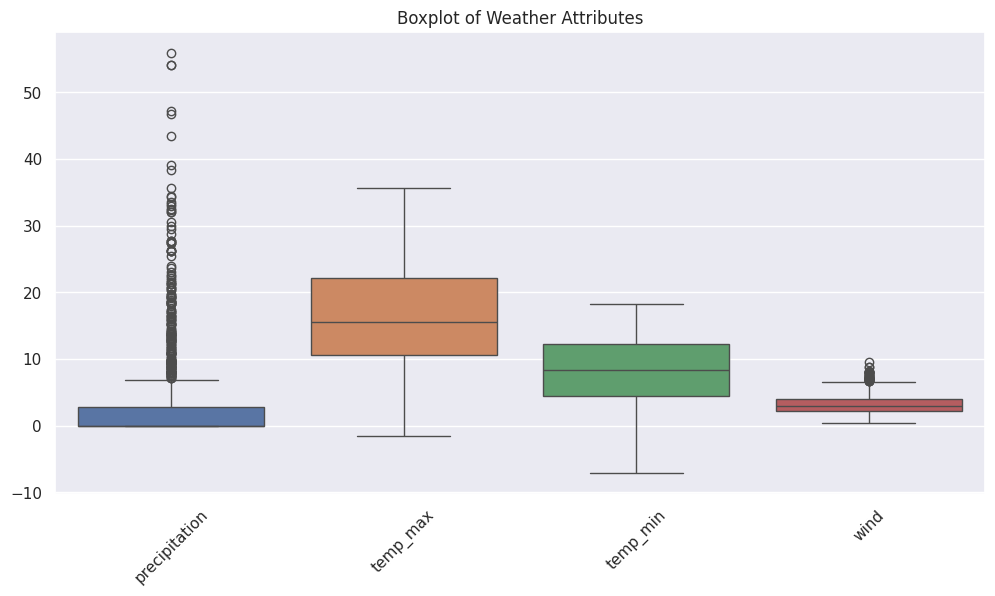

In [ ]:
sns.boxplot(data=data)

In [ ]:
def impute_outliers_IQR(data):
   q1=data.quantile(0.25)
   q3=data.quantile(0.75)
   IQR=q3-q1
   upper = data[~(data>(q3+1.5*IQR))].max()
   lower = data[~(data<(q1-1.5*IQR))].min()
   data = np.where(data > upper,data.mean(),np.where(data < lower, data.mean(), data))
   return data

In [ ]:
data['precipitation'] = impute_outliers_IQR(data['precipitation'])
data['wind'] = impute_outliers_IQR(data['wind'])

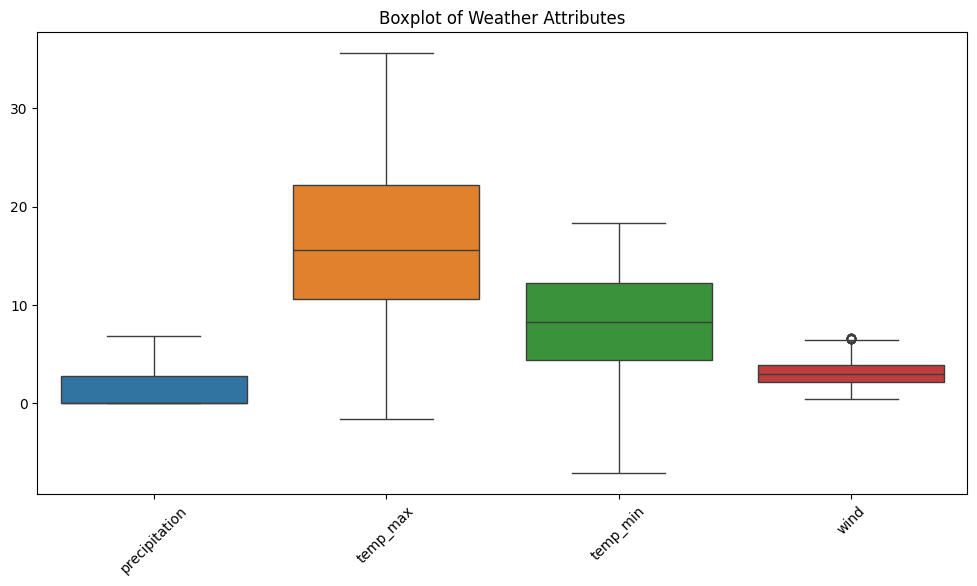

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=data)
plt.title('Boxplot of Weather Attributes')
plt.xticks(rotation=45)
plt.show()

#Data Visualization

<ipython-input-13-be62aa09b6d9>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['temp_max'])


<Axes: xlabel='temp_max', ylabel='Density'>

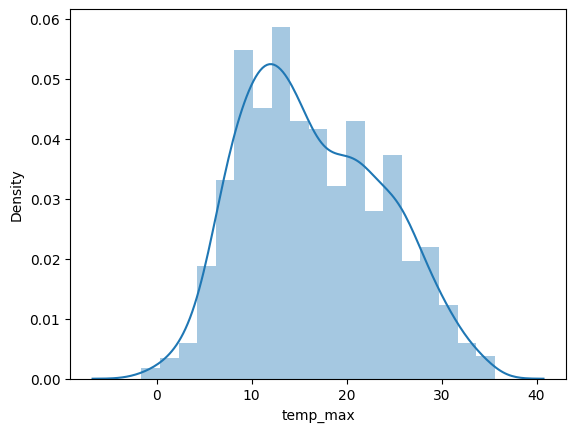

In [ ]:
sns.distplot(data['temp_max'])

<ipython-input-14-39610660fe27>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['temp_min'])


<Axes: xlabel='temp_min', ylabel='Density'>

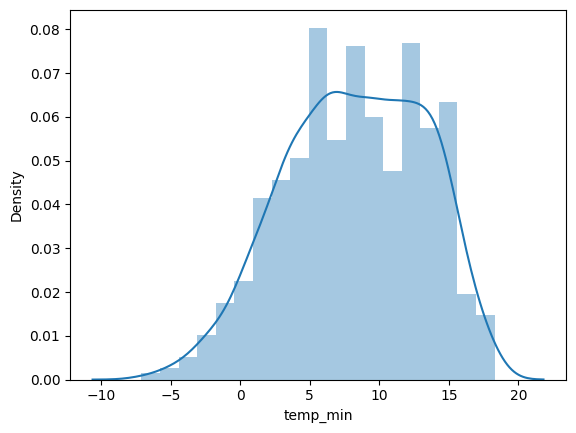

In [ ]:
sns.distplot(data['temp_min'])

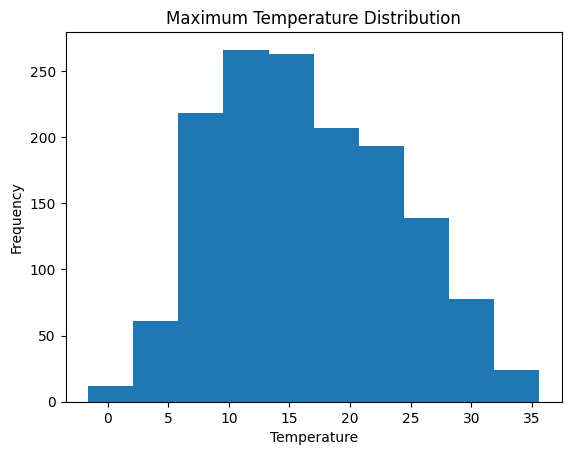

In [ ]:
plt.hist(data['temp_max'])
plt.title('Maximum Temperature Distribution')
plt.xlabel('Temperature')
plt.ylabel('Frequency')
plt.show()

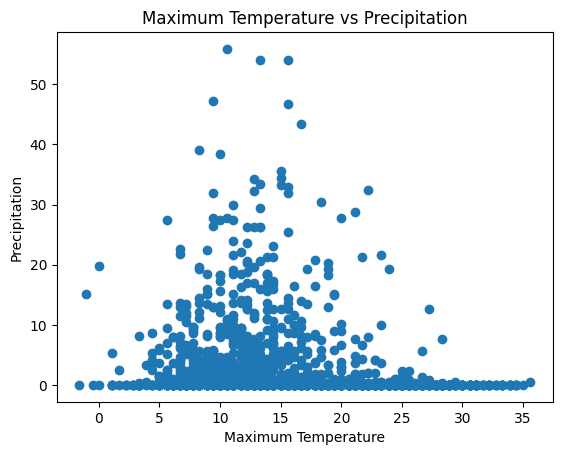

In [ ]:
plt.scatter(data['temp_max'], data['precipitation'])
plt.title('Maximum Temperature vs Precipitation')
plt.xlabel('Maximum Temperature')
plt.ylabel('Precipitation')
plt.show()

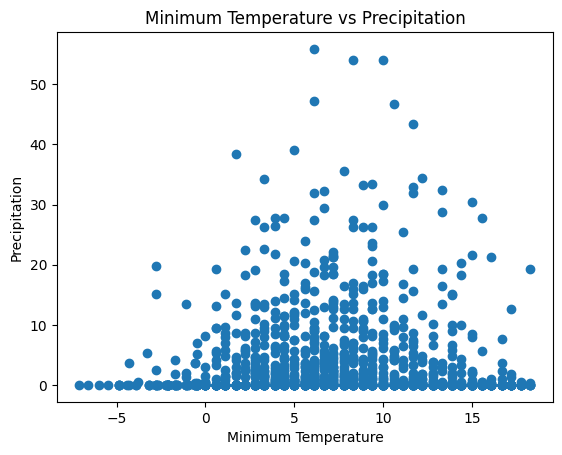

In [ ]:
plt.scatter(data['temp_min'], data['precipitation'])
plt.title('Minimum Temperature vs Precipitation')
plt.xlabel('Minimum Temperature')
plt.ylabel('Precipitation')
plt.show()

<Axes: xlabel='precipitation', ylabel='temp_min'>

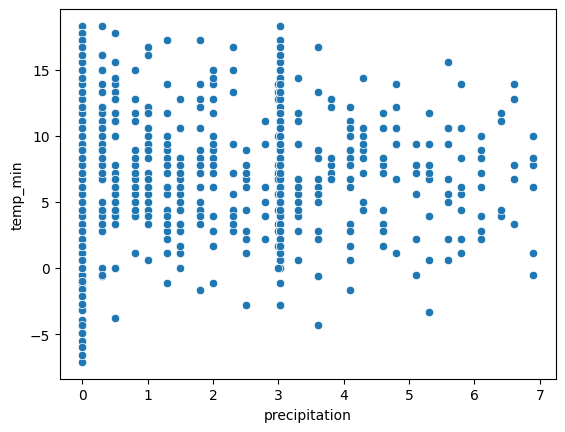

In [ ]:
sns.scatterplot(x='precipitation', y='temp_min', data=data)

<Axes: xlabel='precipitation', ylabel='temp_max'>

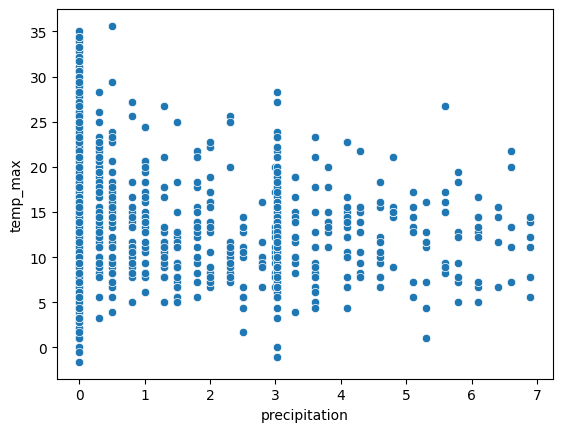

In [ ]:
sns.scatterplot(x='precipitation', y='temp_max', data=data)

<Axes: xlabel='weather', ylabel='wind'>

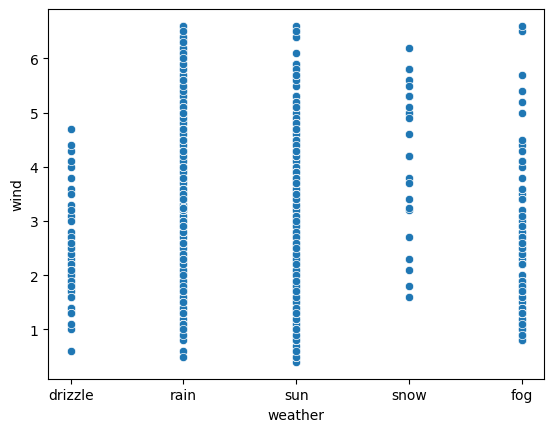

In [ ]:
sns.scatterplot(x='weather', y='wind', data=data)

<Axes: ylabel='count'>

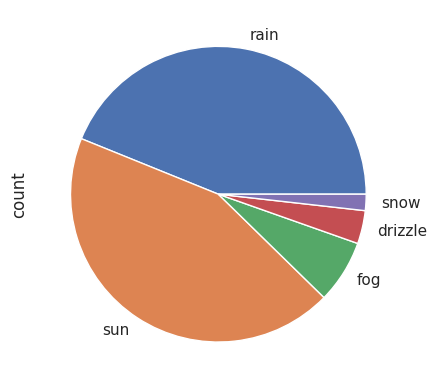

In [ ]:
data['weather'].value_counts().plot.pie()

<Axes: ylabel='count'>

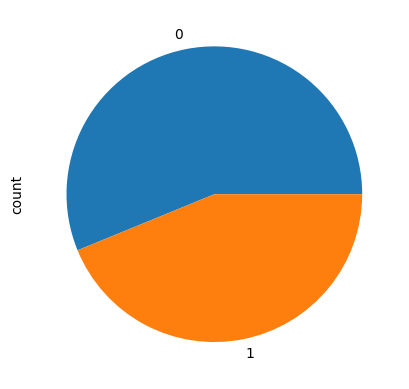

In [ ]:
data['is_sunny'] = data['weather'].map(lambda x: 1 if x == 'sun' else 0)
data['is_sunny'].value_counts().plot.pie()

In [ ]:
df_time = data[['date', 'is_sunny', 'weather']].copy()
df_time

,date,is_sunny,weather
0,2012-01-01,0,drizzle
1,2012-01-02,0,rain
2,2012-01-03,0,rain
3,2012-01-04,0,rain
4,2012-01-05,0,rain
...,...,...,...
1456,2015-12-27,0,rain
1457,2015-12-28,0,rain
1458,2015-12-29,0,fog
1459,2015-12-30,1,sun


<Axes: >

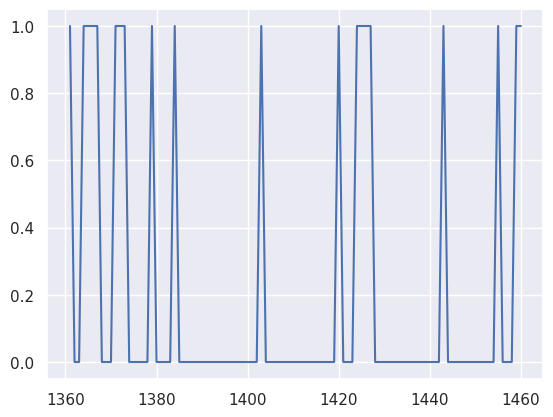

In [ ]:
df_time.iloc[-100:]['is_sunny'].plot()

<ipython-input-84-8db81ed8f413>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='weather', data=data, palette="ch:start=.2,rot=-.3")


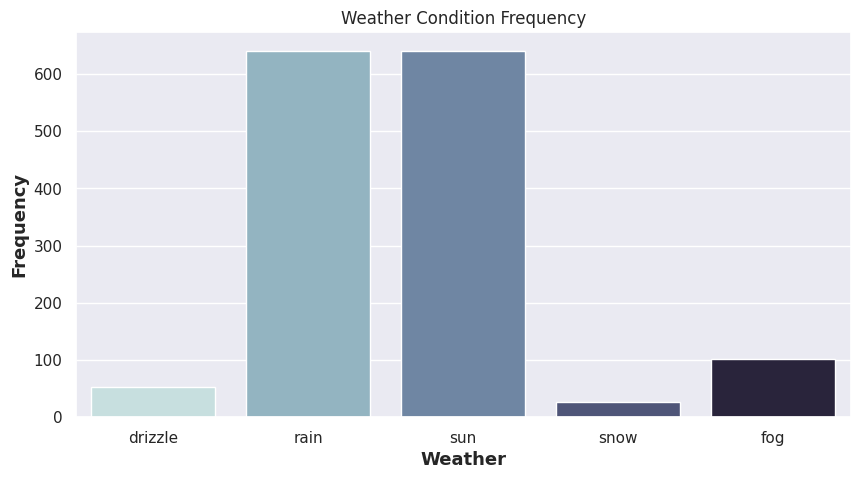

In [ ]:
plt.figure(figsize=(10, 5))
sns.set_theme()
sns.countplot(x='weather', data=data, palette="ch:start=.2,rot=-.3")
plt.title('Weather Condition Frequency')
plt.xlabel("Weather", fontweight='bold', size=13)
plt.ylabel("Frequency", fontweight='bold', size=13)
plt.show()

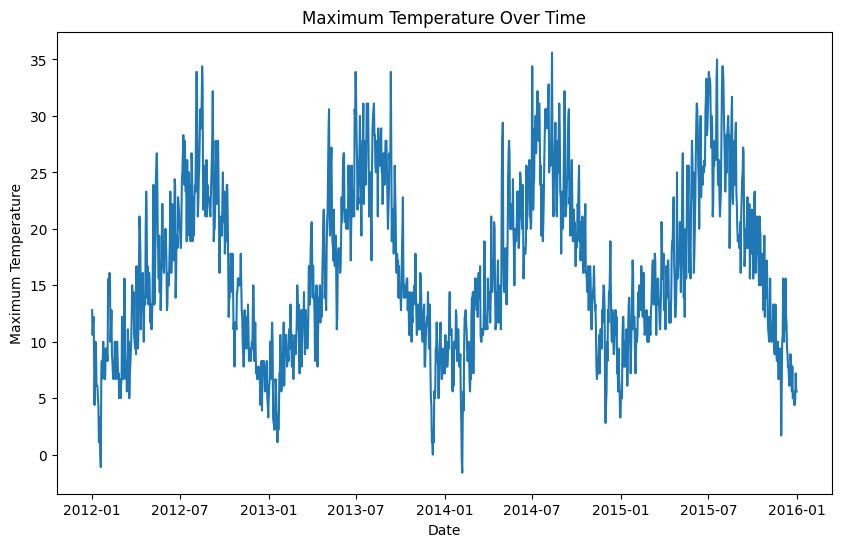

In [ ]:
data['date'] = pd.to_datetime(data['date'])
plt.figure(figsize=(10,6))
plt.plot(data['date'], data['temp_max'])
plt.title('Maximum Temperature Over Time')
plt.xlabel('Date')
plt.ylabel('Maximum Temperature')

plt.show()

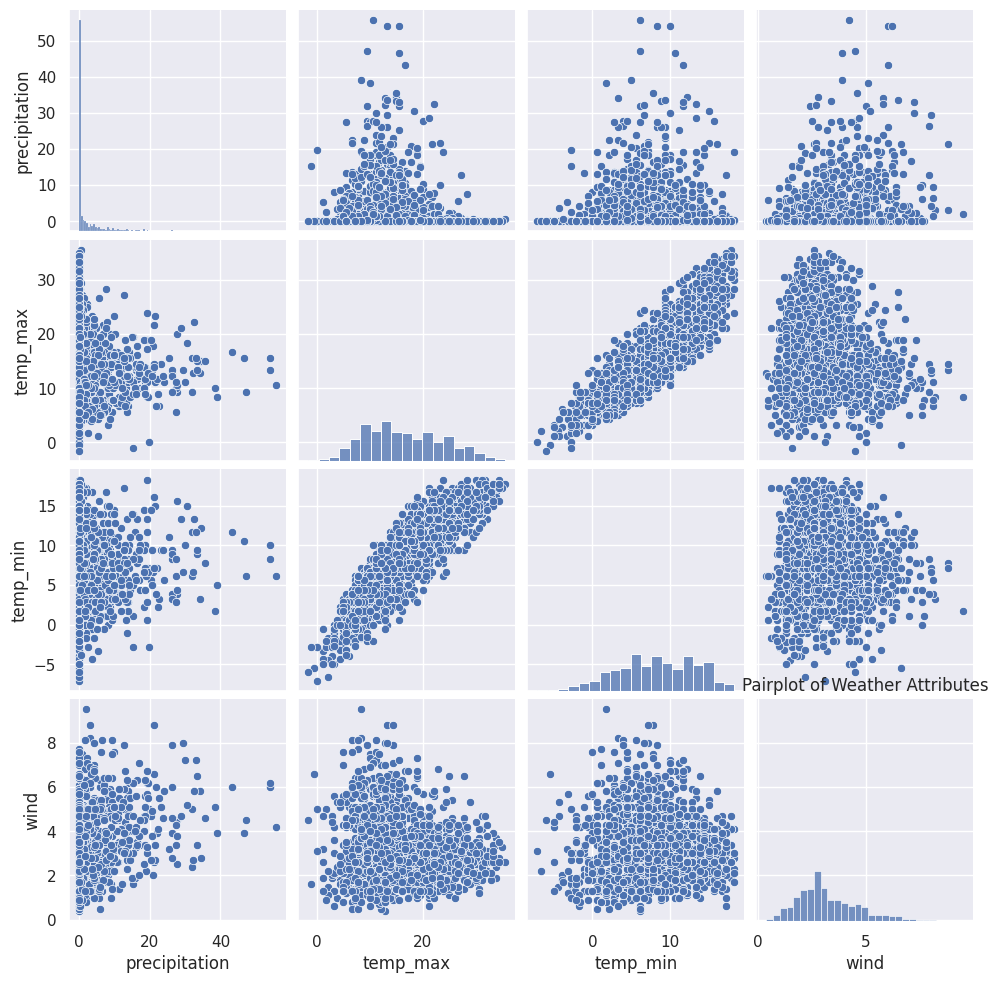

In [ ]:
sns.pairplot(data)
plt.title('Pairplot of Weather Attributes')
plt.show()

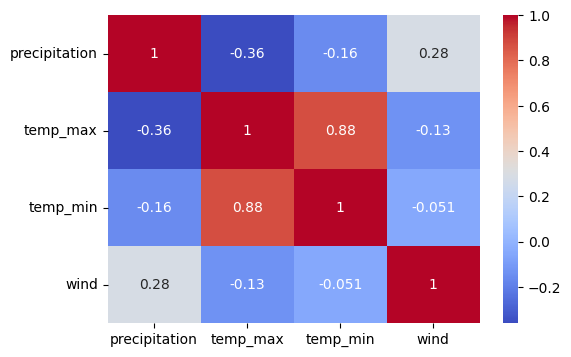

In [ ]:
continuous_cols = data.select_dtypes(include='number').columns
correlation_matrix = data[continuous_cols].corr()
plt.figure(figsize=(6,4)) # size
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

In [ ]:
print(data['date'].dtypes)

# Convert 'date' column to datetime format
data['date'] = pd.to_datetime(data['date'])

# Extract year, month, and day features
data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month
data['day'] = data['date'].dt.day

datetime64[ns]


In [ ]:
X = data[['precipitation', 'temp_max', 'temp_min', 'wind']]
Y = data['weather']

In [ ]:
!pip install catboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 MB 8.9 MB/s eta 0:00:00


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

LOGISTIC REGRESSION

In [ ]:
model1 = LogisticRegression()
model1.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
pred1 = model1.predict(X_test)
# Evaluate the model
accuracy1 = accuracy_score(y_test, pred1)
print("Accuracy:", accuracy1)

Accuracy: 0.8451025056947609


RANDOM FOREST CLASSIFIER

In [ ]:
model2 = RandomForestClassifier()
model2.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
pred2 = model2.predict(X_test)
pred2

In [ ]:
accuracy2 = accuracy_score(y_test, pred2)
print("Accuracy:", accuracy1)

Accuracy: 0.8451025056947609


EXTRA TREES CLASSIFIER

In [ ]:
model3 = ExtraTreesClassifier()
model3.fit(X_train, y_train)

ExtraTreesClassifier()

In [ ]:
pred3 = model3.predict(X_test)
pred3

In [ ]:
# Evaluate the model
accuracy3 = accuracy_score(y_test, pred3)
print("Accuracy:", accuracy3)

Accuracy: 0.8132118451025057


VOTING CLASSIFIER

In [ ]:
model4 = VotingClassifier(estimators=[('dt', model1), ('svc', model2), ('lr', model3)])
model4.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


VotingClassifier(estimators=[('dt', LogisticRegression()),
                             ('svc', RandomForestClassifier()),
                             ('lr', ExtraTreesClassifier())])

In [ ]:
pred4 = model4.predict(X_test)
pred4

In [ ]:
# Evaluate the model
accuracy4 = accuracy_score(y_test, pred4)
print("Accuracy:", accuracy4)

Accuracy: 0.826879271070615


DECISION TREE CLASSIFIER

In [ ]:
model5 = DecisionTreeClassifier(max_leaf_nodes=10, random_state=42)
model5.fit(X_train, y_train)

DecisionTreeClassifier(max_leaf_nodes=10, random_state=42)

In [ ]:
pred5 = model5.predict(X_test)
# Evaluate the model
accuracy5 = accuracy_score(y_test, pred5)
print("Accuracy:", accuracy5)

Accuracy: 0.7334851936218679


CAT BOOST CLASSIFIER

In [ ]:
model6 = CatBoostClassifier()
model6.fit(X_train, y_train)

In [ ]:
pred6 = model6.predict(X_test)
# Evaluate the model
accuracy6 = accuracy_score(y_test, pred6)
print("Accuracy:", accuracy6)

Accuracy: 0.835990888382688


MLP CLASSIFIER

In [ ]:
model7 = MLPClassifier()
model7.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier()

In [ ]:
pred7 = model7.predict(X_test)
# Evaluate the model
accuracy7 = accuracy_score(y_test, pred7)
print("Accuracy:", accuracy7)

Accuracy: 0.8337129840546698


SVC

In [ ]:
model8 = SVC()
model8.fit(x_train, y_train)

SVC()

In [ ]:
pred8 = model8.predict(x_test)
# Evaluate the model
accuracy8 = accuracy_score(y_test, pred8)
print("Accuracy:", accuracy8)

Accuracy: 0.44368600682593856


In [ ]:
le = LabelEncoder()
data['weather_label'] = le.fit_transform(data['weather'])
weather_dict = {label: value for label, value in zip(data['weather_label'], data['weather'])}
data = data.drop('weather', axis=1).set_index('date')
data.head()

,precipitation,temp_max,temp_min,wind,weather_label
date,,,,,
2012-01-01,0.0,12.8,5.0,4.7,0
2012-01-02,10.9,10.6,2.8,4.5,2
2012-01-03,0.8,11.7,7.2,2.3,2
2012-01-04,20.3,12.2,5.6,4.7,2
2012-01-05,1.3,8.9,2.8,6.1,2


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
x = data.drop(["weather_label"], axis= 1)
y = data["weather_label"]
x_train, x_test ,y_train ,y_test = train_test_split(x,y, test_size=0.2,random_state=2)

In [ ]:
mse = mean_squared_error(y_test, pred8)
rmse = mse ** 0.5
print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 1.6606261412152261


In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

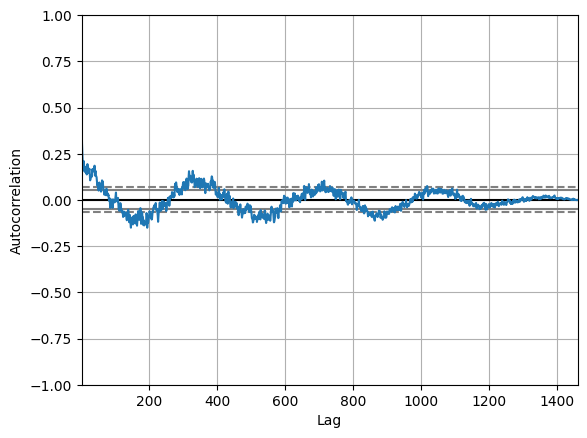

In [ ]:
pd.plotting.autocorrelation_plot(data['is_sunny'])

<Axes: >

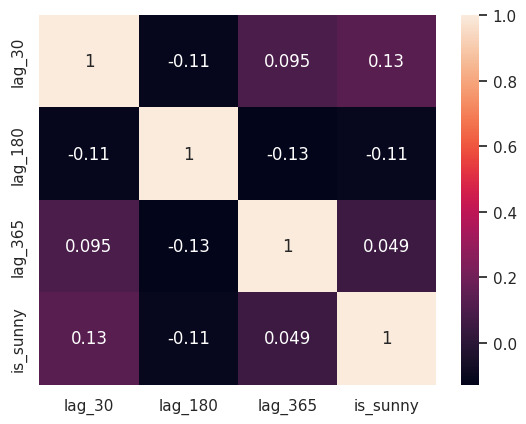

In [ ]:
data['lag_30'] = data['is_sunny'].shift(30)
data['lag_180'] = data['is_sunny'].shift(180)
data['lag_365'] = data['is_sunny'].shift(365)

sns.heatmap(data[['lag_30', 'lag_180', 'lag_365', 'is_sunny']].corr(), annot=True)

ROLLING FEATURE ANALYSIS

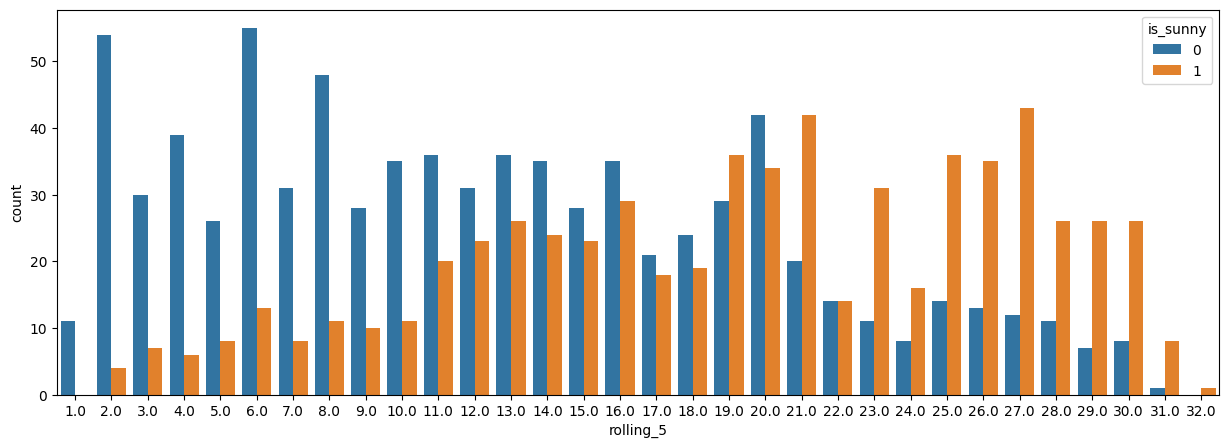

In [ ]:
data['rolling_5'] = data['is_sunny'].rolling(35).sum()

plt.figure(figsize = (15,5))
sns.countplot(data, x='rolling_5', hue='is_sunny')
plt.show()

NUMERICAL FEATURE ANALYSIS

In [ ]:
y = data['is_sunny'][35:]
X = data.drop(['date', 'is_sunny', 'weather', 'lag_180', 'lag_365', 'precipitation', 'temp_max', 'temp_min', 'wind'], axis = 1)[35:]

X['dayofweek'] = data['date'].dt.dayofweek
X['day'] = data['date'].dt.day
X['month'] = data['date'].dt.month
X['year'] = data['date'].dt.year

X

,lag_30,rolling_5,dayofweek,day,month,year
35,0.0,8.0,6,5,2,2012
36,0.0,9.0,0,6,2,2012
37,1.0,9.0,1,7,2,2012
38,0.0,9.0,2,8,2,2012
39,0.0,9.0,3,9,2,2012
...,...,...,...,...,...,...
1456,1.0,6.0,6,27,12,2015
1457,1.0,6.0,0,28,12,2015
1458,0.0,6.0,1,29,12,2015
1459,0.0,6.0,2,30,12,2015


NUMERICAL FEATURE ANALYSIS

In [ ]:
num_cols = ['precipitation', 'temp_max', 'temp_min', 'wind']

<ipython-input-112-f02c8698f7d5>:2: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data, hue='is_sunny', x=column)


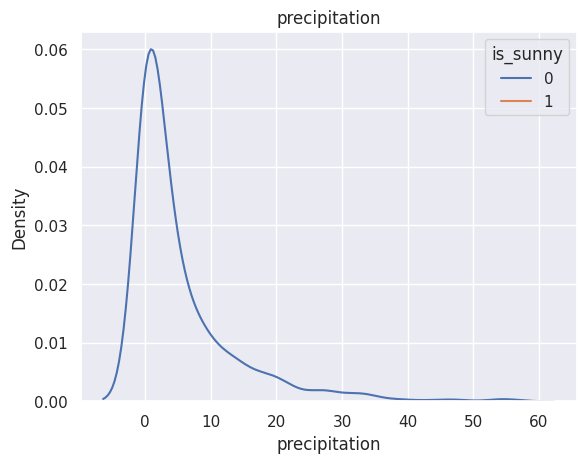

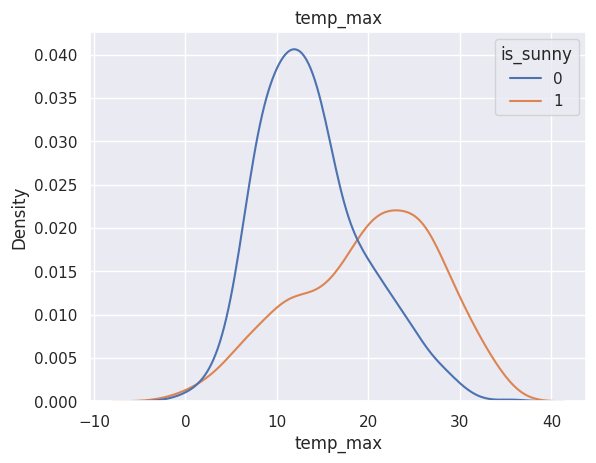

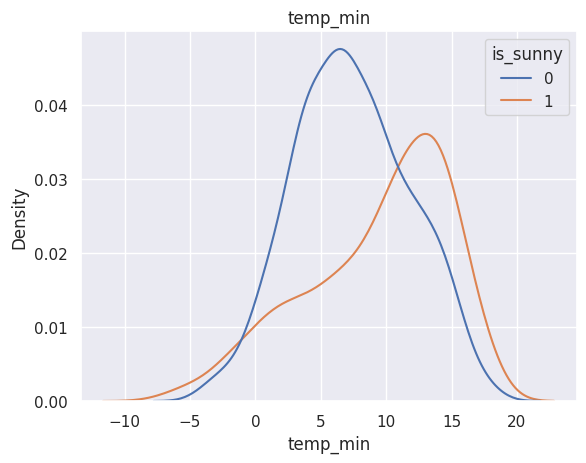

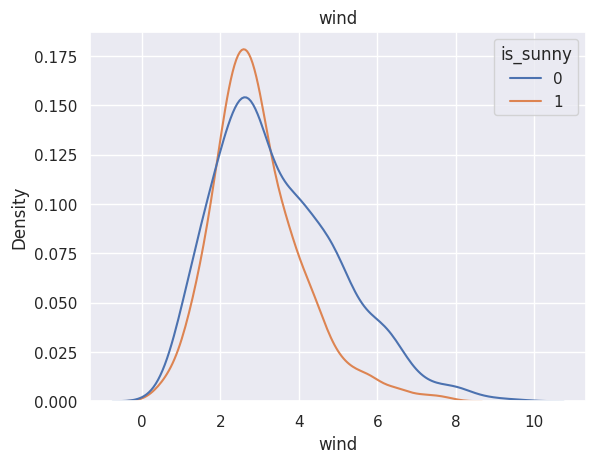

In [ ]:
for column in num_cols:
    sns.kdeplot(data, hue='is_sunny', x=column)
    plt.title(column)
    plt.show()

<Axes: xlabel='precipitation_rolling_5', ylabel='Density'>

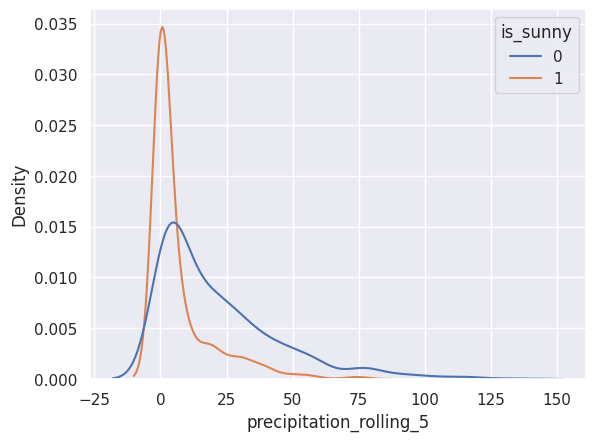

In [ ]:
data['precipitation_rolling_5'] = data['precipitation'].rolling(5).sum()
sns.kdeplot(data, x = 'precipitation_rolling_5', hue = 'is_sunny')

<Axes: xlabel='precipitation_rolling_5', ylabel='precipitation'>

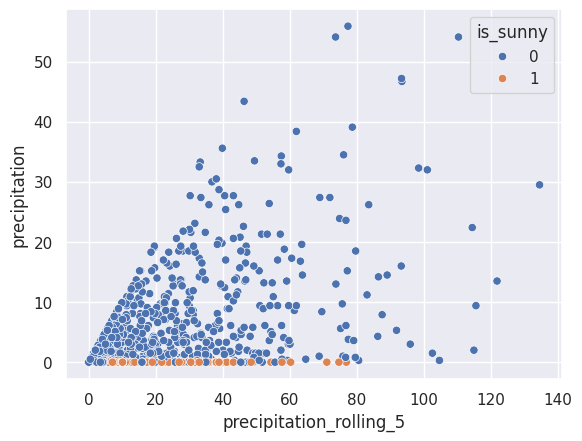

In [ ]:
sns.scatterplot(data, x = 'precipitation_rolling_5', y='precipitation', hue='is_sunny')

<Axes: xlabel='temp_max', ylabel='Density'>

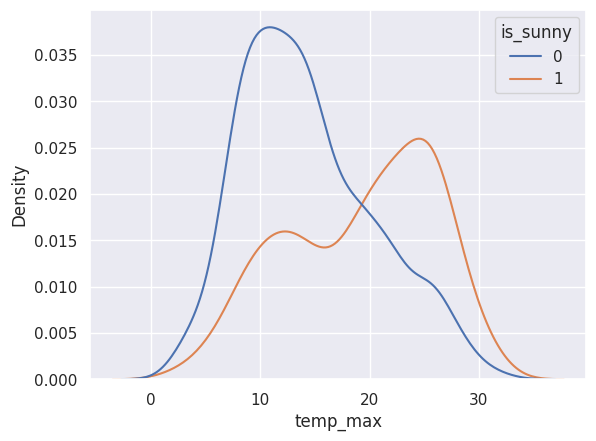

In [ ]:
sns.kdeplot(data, x=data['temp_max'].rolling(7).mean(), hue='is_sunny')

<Axes: xlabel='temp_min', ylabel='Density'>

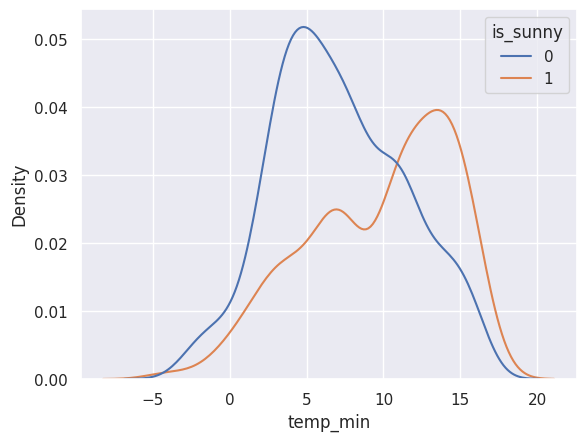

In [ ]:
sns.kdeplot(data, x=data['temp_min'].rolling(7).mean(), hue='is_sunny')

<Axes: xlabel='temp_max_roll_7', ylabel='temp_min_roll_7'>

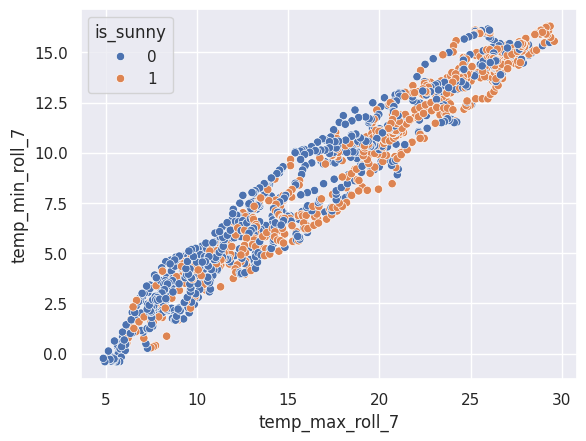

In [ ]:
data['temp_max_roll_7'] = data['temp_max'].rolling(20).mean()
data['temp_min_roll_7'] = data['temp_min'].rolling(20).mean()

sns.scatterplot(data, x='temp_max_roll_7', y='temp_min_roll_7', hue='is_sunny')

OPTIMIZATION

In [ ]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
import os
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style("dark")
sns.set_palette("rocket")

In [ ]:
df = pd.read_csv("seattle-weather.csv",index_col="date",parse_dates=True)
df_temp = df["temp_max"]

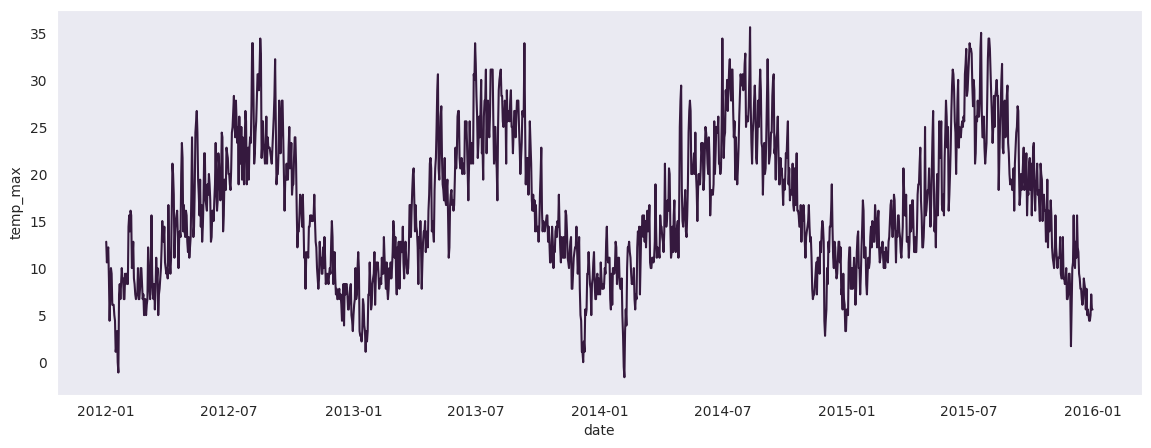

In [ ]:
plt.figure(figsize=(14,5))
sns.lineplot(df_temp);

In [ ]:
def df_to_XY(df,window_size=10):
    df_np = df_temp.to_numpy()
    X = []
    y = []
    for i in range(len(df_np)-window_size):
        row = [[a] for a in df_np[i:i+window_size]]
        X.append(row)
        target = df_np[i+window_size]
        y.append(target)
    return np.array(X),np.array(y)

In [ ]:
WINDOW = 10
X,y = df_to_XY(df,WINDOW)
print(len(X),len(y))
X_train = X[:800]
y_train = y[:800]
X_val = X[800:1000]
y_val = y[800:1000]
X_test = X[1000:]
y_test = y[1000:]

1451 1451


In [ ]:
X.shape

(1451, 10, 1)

MODEL

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
import keras
from keras import layers


In [ ]:
model = Sequential()
model.add(LSTM(64,input_shape=(WINDOW,1)))
model.add(Dense(32,"relu"))
model.add(Dropout(0.2))
model.add(Dense(16,"relu"))
model.add(Dense(1,"linear"))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 64)                16896     
                                                                 
 dense (Dense)               (None, 32)                2080      
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 16)                528       
                                                                 
 dense_2 (Dense)             (None, 1)                 17        
                                                                 
Total params: 19521 (76.25 KB)
Trainable params: 19521 (76.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
earlyStopping = EarlyStopping(monitor="val_root_mean_squared_error",patience=3,start_from_epoch=5,restore_best_weights=True,)
model.compile(loss=MeanSquaredError(),optimizer=Adam(learning_rate=0.0001),metrics=RootMeanSquaredError())

In [ ]:
history = model.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=100, callbacks=[earlyStopping])

Epoch 1/100
25/25 [==============================] - 5s 55ms/step - loss: 287.9337 - root_mean_squared_error: 16.9686 - val_loss: 506.5452 - val_root_mean_squared_error: 22.5066
Epoch 2/100
25/25 [==============================] - 0s 16ms/step - loss: 283.7152 - root_mean_squared_error: 16.8438 - val_loss: 501.1630 - val_root_mean_squared_error: 22.3867
Epoch 3/100
25/25 [==============================] - 0s 15ms/step - loss: 280.1877 - root_mean_squared_error: 16.7388 - val_loss: 495.7255 - val_root_mean_squared_error: 22.2649
Epoch 4/100
25/25 [==============================] - 0s 16ms/step - loss: 276.0574 - root_mean_squared_error: 16.6150 - val_loss: 490.4949 - val_root_mean_squared_error: 22.1471
Epoch 5/100
25/25 [==============================] - 0s 11ms/step - loss: 271.7666 - root_mean_squared_error: 16.4853 - val_loss: 484.5177 - val_root_mean_squared_error: 22.0118
Epoch 6/100
25/25 [==============================] - 0s 8ms/step - loss: 266.9103 - root_mean_squared_error: 1

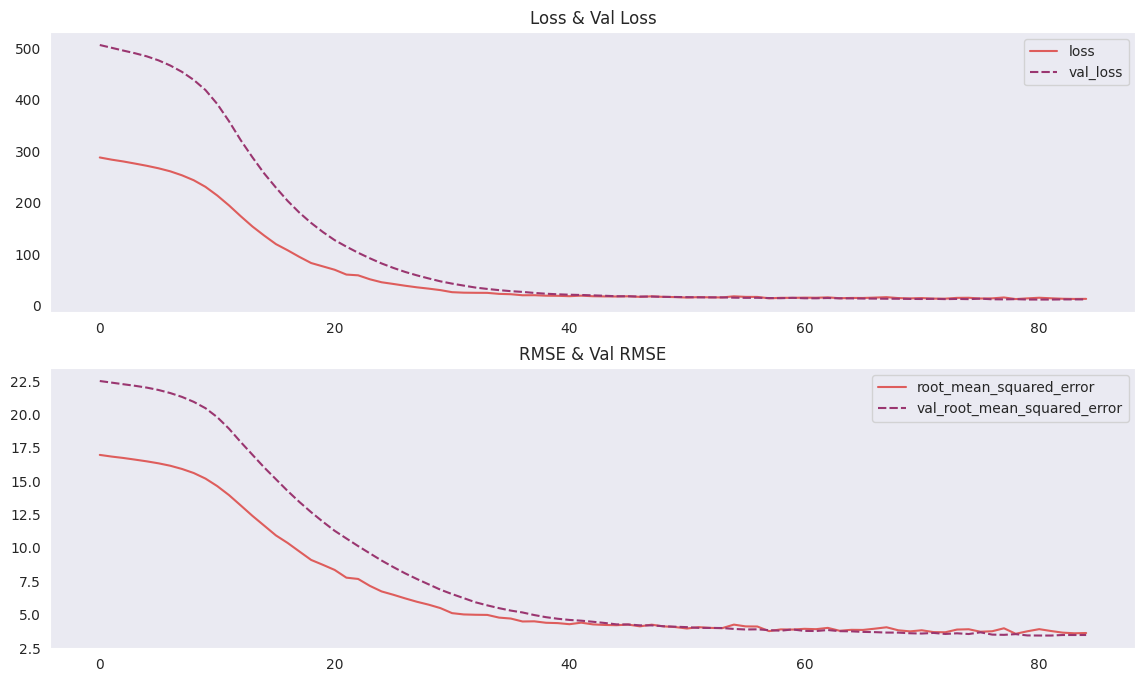

In [ ]:
his = pd.DataFrame(history.history)
his.columns
history_loss = his[['loss', 'val_loss']]
history_rmse =  his[['root_mean_squared_error', 'val_root_mean_squared_error']]

fig,axes = plt.subplots(2,1,figsize=(14,8))
plt.subplot(2,1,1)
plt.title("Loss & Val Loss")
sns.lineplot(history_loss,palette="flare");

plt.subplot(2,1,2)
plt.title("RMSE & Val RMSE")
sns.lineplot(history_rmse,palette="flare");

In [ ]:
train_pred = model.predict(X_train).flatten()
val_pred = model.predict(X_val).flatten()
test_pred = model.predict(X_test).flatten()

15/15 [==============================] - 0s 5ms/step


In [ ]:
print("Train Predict Shape:", train_pred.shape)
print("Test Predict Shape:", test_pred.shape)


Train Predict Shape: (800,)
Test Predict Shape: (451,)


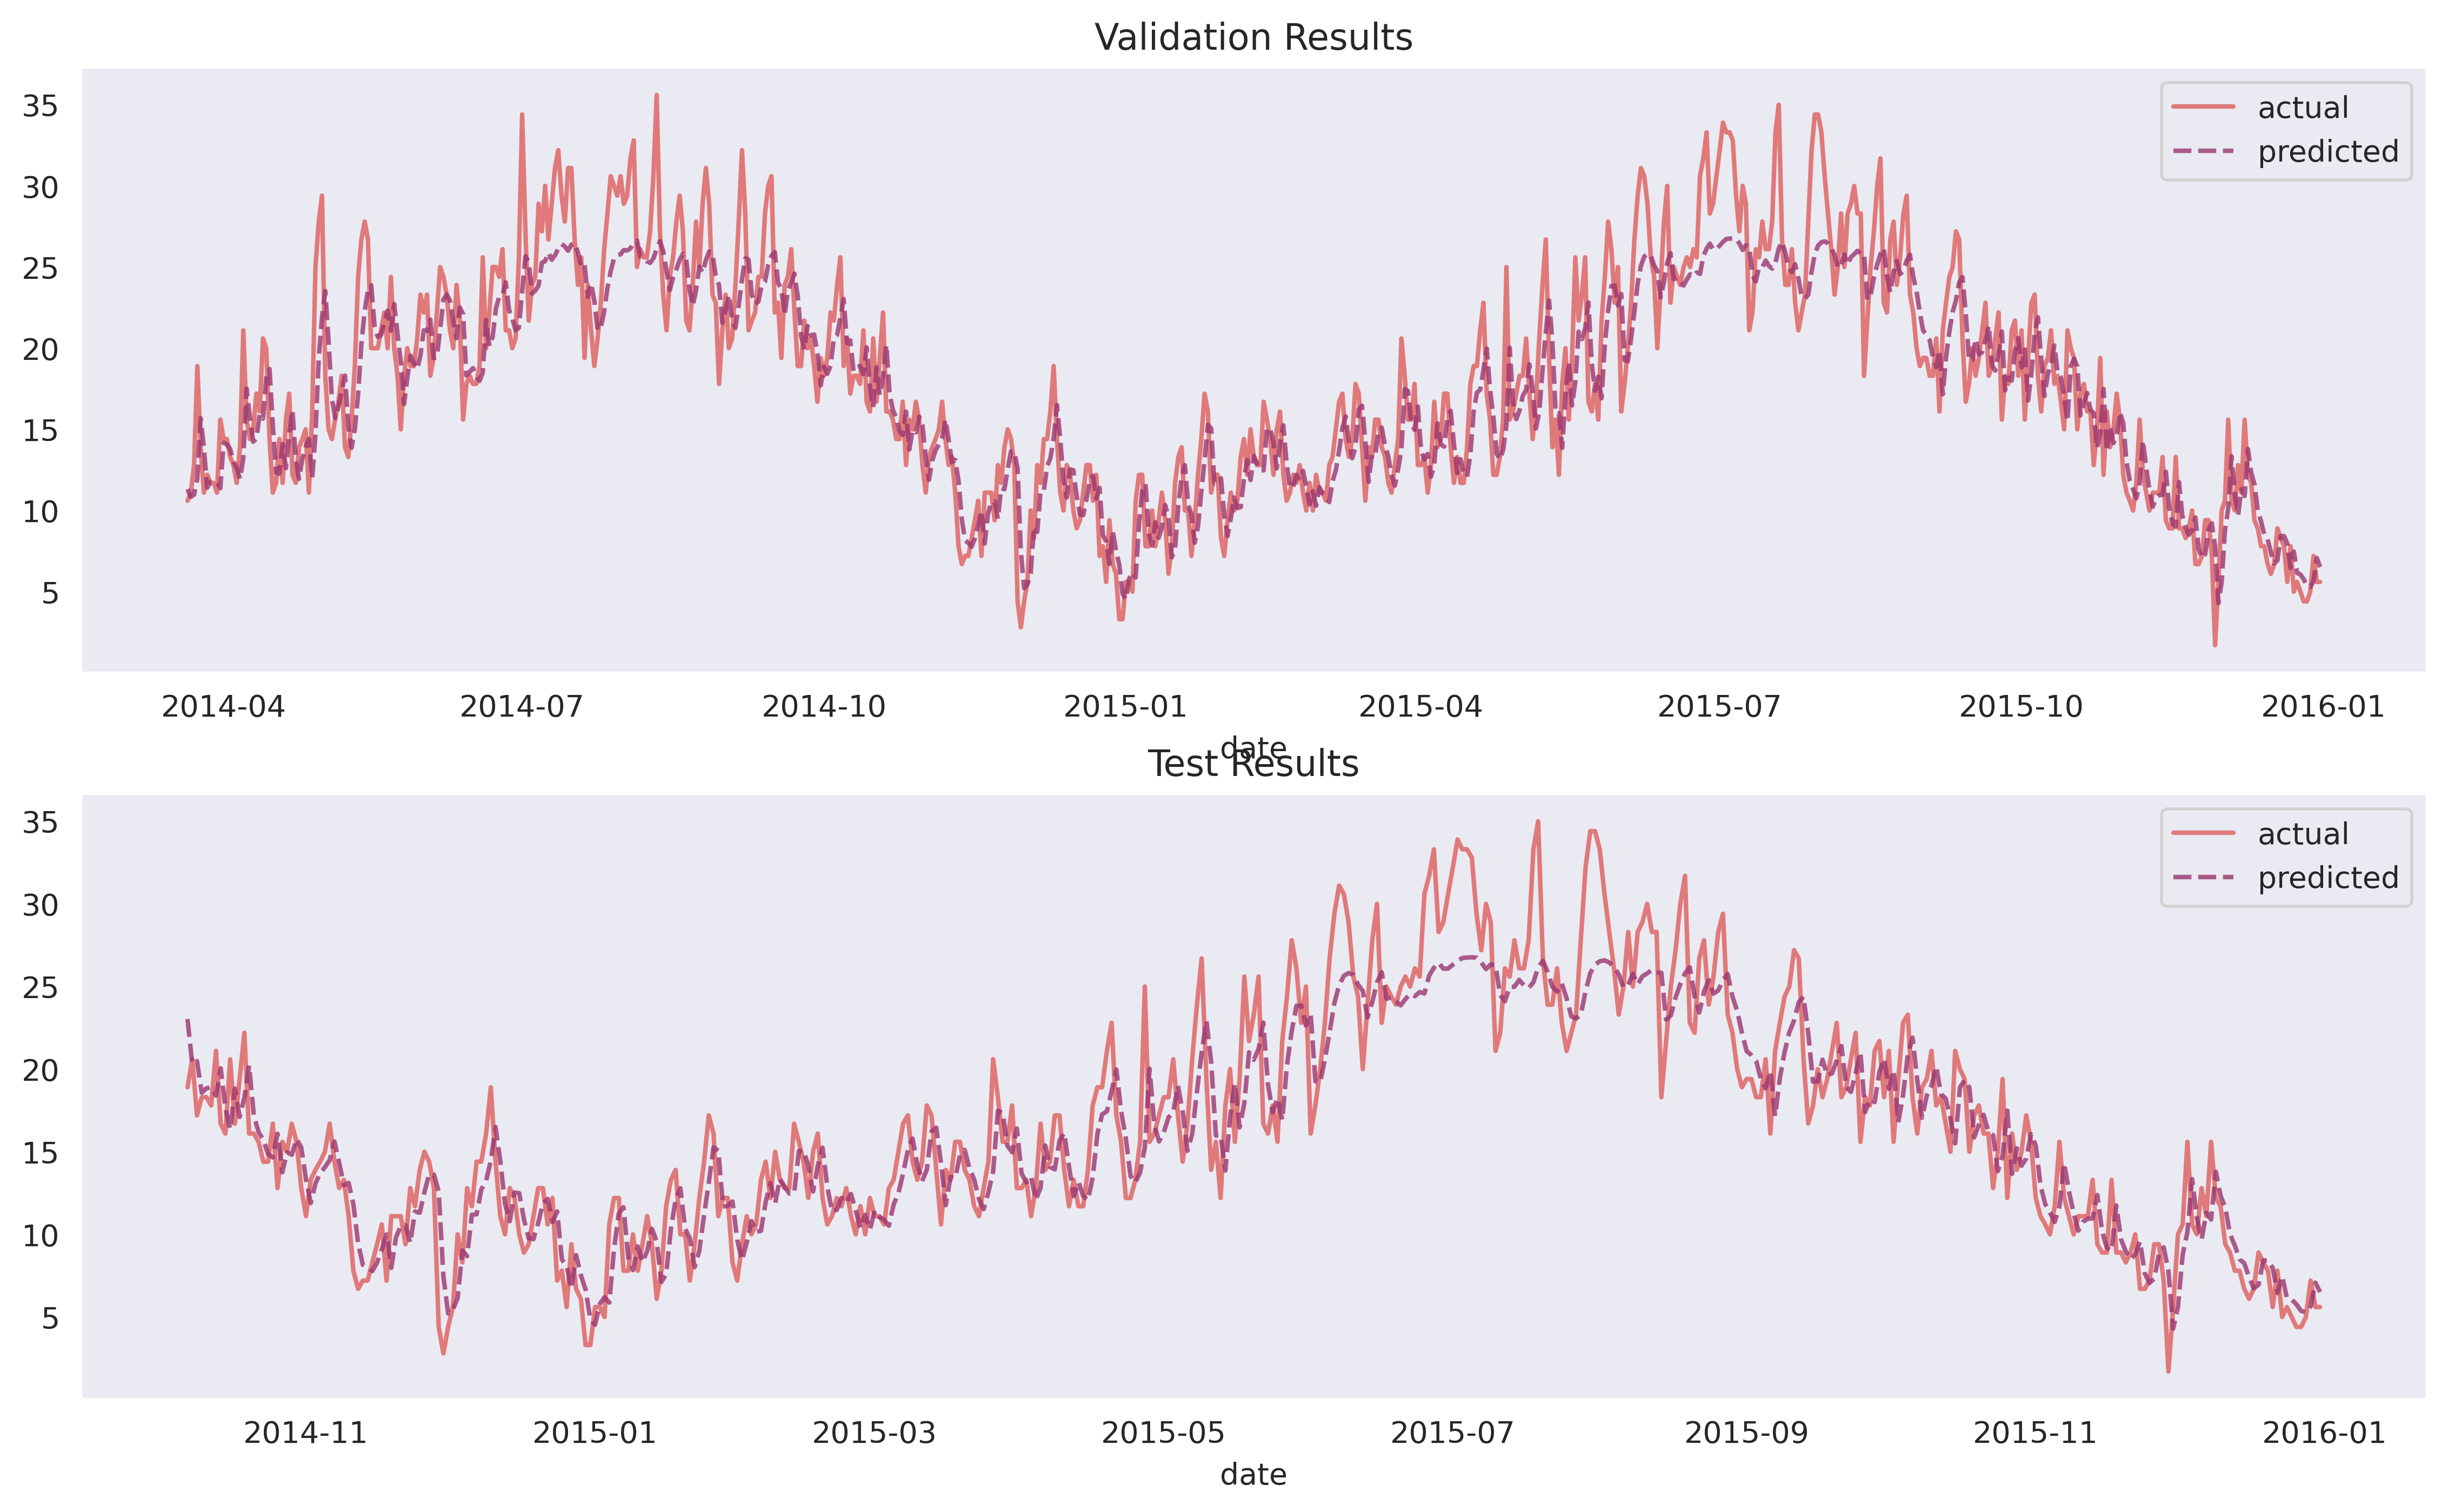

In [ ]:
pred = np.concatenate([train_pred,val_pred,test_pred])
df_pred = pd.DataFrame(df["temp_max"].copy())
df_pred.columns=["actual"]
df_pred = df_pred[WINDOW:]
df_pred["predicted"] = pred

fig,axes = plt.subplots(2,1,figsize=(14,8),dpi=400)

plt.subplot(2,1,1)
plt.title("Validation Results")
sns.lineplot(df_pred[800:],alpha=0.8,palette="flare",linestyle=None);

plt.subplot(2,1,2)
plt.title("Test Results")
sns.lineplot(df_pred[1000:],alpha=0.8,palette="flare",linestyle=None);

In [ ]:
from sklearn.metrics import mean_squared_error
trainPredict_col1 = train_pred
testPredict_col1 = test_pred
trainScore = np.sqrt(mean_squared_error(y_train.flatten(), trainPredict_col1))
print('Train Score: %.2f RMSE' % (trainScore))

testScore = np.sqrt(mean_squared_error(y_test.flatten(), testPredict_col1))
print('Test Score: %.2f RMSE' % (testScore))

Train Score: 2.77 RMSE
Test Score: 2.92 RMSE


In [ ]:
weather = pd.read_csv("seattle-weather.csv")
weather.head()

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
df = pd.DataFrame({'Actual': y_test, 'Presicted':y_pred})
df1 = df.head(10)

In [ ]:
#visual comparison
df1.plot(kind = 'bar', figsize = (10,6))
plt.grid(which='major', linestyle='-', linewidth='0.5', color='green')
plt.grid(which='minor', linestyle='-', linewidth='0.5', color='black')
plt.show()

array([[<Axes: xlabel='precipitation', ylabel='precipitation'>,
        <Axes: xlabel='temp_max', ylabel='precipitation'>,
        <Axes: xlabel='temp_min', ylabel='precipitation'>,
        <Axes: xlabel='wind', ylabel='precipitation'>],
       [<Axes: xlabel='precipitation', ylabel='temp_max'>,
        <Axes: xlabel='temp_max', ylabel='temp_max'>,
        <Axes: xlabel='temp_min', ylabel='temp_max'>,
        <Axes: xlabel='wind', ylabel='temp_max'>],
       [<Axes: xlabel='precipitation', ylabel='temp_min'>,
        <Axes: xlabel='temp_max', ylabel='temp_min'>,
        <Axes: xlabel='temp_min', ylabel='temp_min'>,
        <Axes: xlabel='wind', ylabel='temp_min'>],
       [<Axes: xlabel='precipitation', ylabel='wind'>,
        <Axes: xlabel='temp_max', ylabel='wind'>,
        <Axes: xlabel='temp_min', ylabel='wind'>,
        <Axes: xlabel='wind', ylabel='wind'>]], dtype=object)

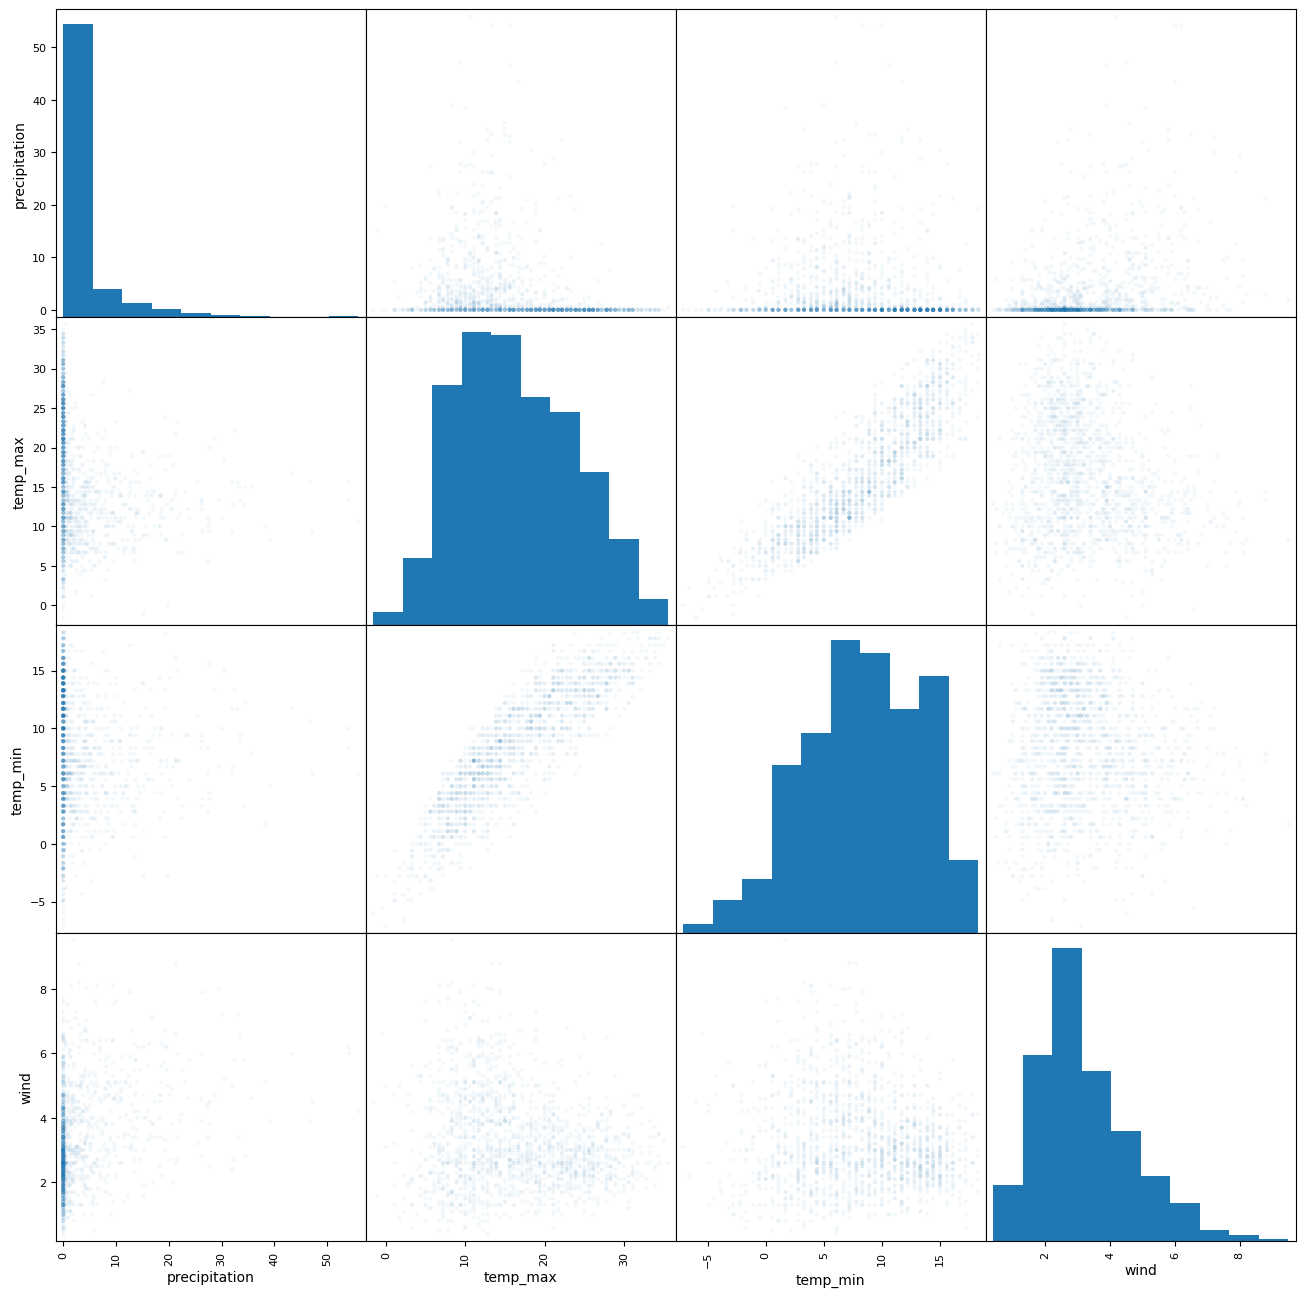

In [ ]:
from pandas.plotting import scatter_matrix
scatter_matrix(data, figsize=(16,16), alpha =0.05, diagonal='hist')